# Pair-image evaluation analysis

Analyses results from `pair_mcq_*.csv` generated with `--pair_mode`.
Each row = one scene queried with **two images** (same object/relation, two different camera angles).

Extra columns vs single-image CSV: `image_path_1`, `image_path_2`, `cam_view_1`, `cam_view_2`.

In [1]:
# ── Shared helpers (copied from eval_analyse.ipynb) ──────────────────────────
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

RELATIONS = ["front", "behind", "left", "right"]

RELATION_MAP = {
    "infrontof": "front",
    "totheleft": "left",
    "totheright": "right",
    "behind": "behind",
}

def extract_camera_perspective_comfort(image_path):
    image_path = str(image_path)
    parts = os.path.dirname(image_path).split("/")
    true_relation = parts[-2]
    folder_name = parts[-1]
    segments = folder_name.split("__")
    cam_segment = segments[-1]
    camera_position = cam_segment.split("_")[-1]

    camera_perspective = None
    if (true_relation == "behind" and camera_position == "left") or (true_relation == "infrontof" and camera_position == "right") or (true_relation == "totheleft" and camera_position == "front") or (true_relation == "totheright" and camera_position == "back"):
        camera_perspective = "right"
    elif (true_relation == "behind" and camera_position == "right") or (true_relation == "infrontof" and camera_position == "left") or (true_relation == "totheleft" and camera_position == "back") or (true_relation == "totheright" and camera_position == "front"):
        camera_perspective = "left"
    elif (true_relation == "behind" and camera_position == "front") or (true_relation == "infrontof" and camera_position == "back") or (true_relation == "totheleft" and camera_position == "right") or (true_relation == "totheright" and camera_position == "left"):
        camera_perspective = "behind"
    elif (true_relation == "behind" and camera_position == "back") or (true_relation == "infrontof" and camera_position == "front") or (true_relation == "totheleft" and camera_position == "left") or (true_relation == "totheright" and camera_position == "right"):
        camera_perspective = "front"
    return true_relation, camera_perspective


def extract_letter_to_relation(prompt):
    prompt = str(prompt)
    mapping = {}
    for letter in ["A", "B", "C", "D"]:
        pattern = rf"{letter}\.\s*(.*?)(?=(?:A|B|C|D)\.\s|$)"
        m = re.search(pattern, prompt, flags=re.IGNORECASE | re.DOTALL)
        if not m:
            continue
        text = m.group(1).lower()
        if "front" in text:   mapping[letter] = "front"
        elif "behind" in text: mapping[letter] = "behind"
        elif "left" in text:   mapping[letter] = "left"
        elif "right" in text:  mapping[letter] = "right"
    return mapping


# Reused directly from eval_analyse.ipynb
def plot_confusion_on_ax(df, ax, title, true_labels):
    plot_df = df[
        df["correct_relation"].isin(true_labels) &
        df["pred_relation"].isin(RELATIONS)
    ].copy()

    if len(plot_df) == 0:
        ax.axis("off")
        ax.set_title(f"{title}\n(no data)")
        return

    cm_df = pd.crosstab(
        plot_df["correct_relation"],
        plot_df["pred_relation"],
        normalize="index"
    ).reindex(index=true_labels, columns=RELATIONS, fill_value=0.0)

    fig_ref = ax.get_figure()
    im = ax.imshow(cm_df.values, cmap="Blues", vmin=0, vmax=1)

    ax.set_xticks(range(len(RELATIONS)))
    ax.set_xticklabels(RELATIONS)
    ax.set_yticks(range(len(true_labels)))
    ax.set_yticklabels(true_labels)

    for i in range(cm_df.shape[0]):
        for j in range(cm_df.shape[1]):
            val = cm_df.iloc[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center")

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")


def analyze_percentages(df):
    rows = []
    for rel in RELATIONS:
        sub = df[df["correct_relation"] == rel]
        total = len(sub)
        if total == 0:
            rows.append({"correct_relation": rel, "total": 0, "correct_pct": 0.0, "opposite_pct": 0.0})
            continue
        correct  = (sub["pred_letter"].astype(str).str.strip() == sub["correct_letter"].astype(str).str.strip()).sum()
        opposite = (sub["pred_letter"].astype(str).str.strip() == sub["opposite_letter"].astype(str).str.strip()).sum()
        rows.append({"correct_relation": rel, "total": total, "correct_pct": correct / total, "opposite_pct": opposite / total})
    return pd.DataFrame(rows)


# ── Pair-specific loader ──────────────────────────────────────────────────────
def load_and_prepare_pair(csv_path):
    df = pd.read_csv(csv_path)

    def get_pred_relation(row):
        letter_map = extract_letter_to_relation(row["mcq_prompt"])
        return letter_map.get(str(row["pred_letter"]).strip(), None)

    df["pred_relation"] = df.apply(get_pred_relation, axis=1)
    df["correct_relation"] = df["correct_relation"].astype(str).str.strip().str.lower()

    r1 = df["image_path_1"].apply(extract_camera_perspective_comfort)
    r2 = df["image_path_2"].apply(extract_camera_perspective_comfort)

    df["object_position"]    = r1.apply(lambda x: RELATION_MAP.get(x[0], x[0]))
    df["cam_perspective_1"]  = r1.apply(lambda x: x[1])
    df["cam_perspective_2"]  = r2.apply(lambda x: x[1])

    df["cam_view_1"] = df["cam_view_1"].astype(str).str.strip()
    df["cam_view_2"] = df["cam_view_2"].astype(str).str.strip()
    df["view1_short"] = df["cam_view_1"].str.replace("cam_", "", regex=False)
    df["view2_short"] = df["cam_view_2"].str.replace("cam_", "", regex=False)

    df["is_correct"]  = df["pred_letter"].astype(str).str.strip() == df["correct_letter"].astype(str).str.strip()
    df["is_opposite"] = df["pred_letter"].astype(str).str.strip() == df["opposite_letter"].astype(str).str.strip()
    return df


print("Helpers loaded.")

Helpers loaded.


In [2]:
base_dir = "./"
lengths  = ["short", "middle", "long"]
models   = ["qwen3vl"]  # ← 按需修改

## 1 — Overall: accuracy table + 4×4 confusion matrix per model


===== MODEL: qwen3vl =====
  Loaded short: 240 rows
  Loaded middle: 240 rows
  Loaded long: 240 rows
  [short]


,correct_relation,total,correct_pct,opposite_pct
0,front,60,0.15,0.000000
1,behind,60,0.00,0.100000
2,left,60,0.30,0.583333
3,right,60,0.35,0.450000


  [middle]


,correct_relation,total,correct_pct,opposite_pct
0,front,60,0.116667,0.033333
1,behind,60,0.033333,0.066667
2,left,60,0.233333,0.583333
3,right,60,0.433333,0.483333


  [long]


,correct_relation,total,correct_pct,opposite_pct
0,front,60,0.200000,0.016667
1,behind,60,0.016667,0.183333
2,left,60,0.200000,0.516667
3,right,60,0.450000,0.350000


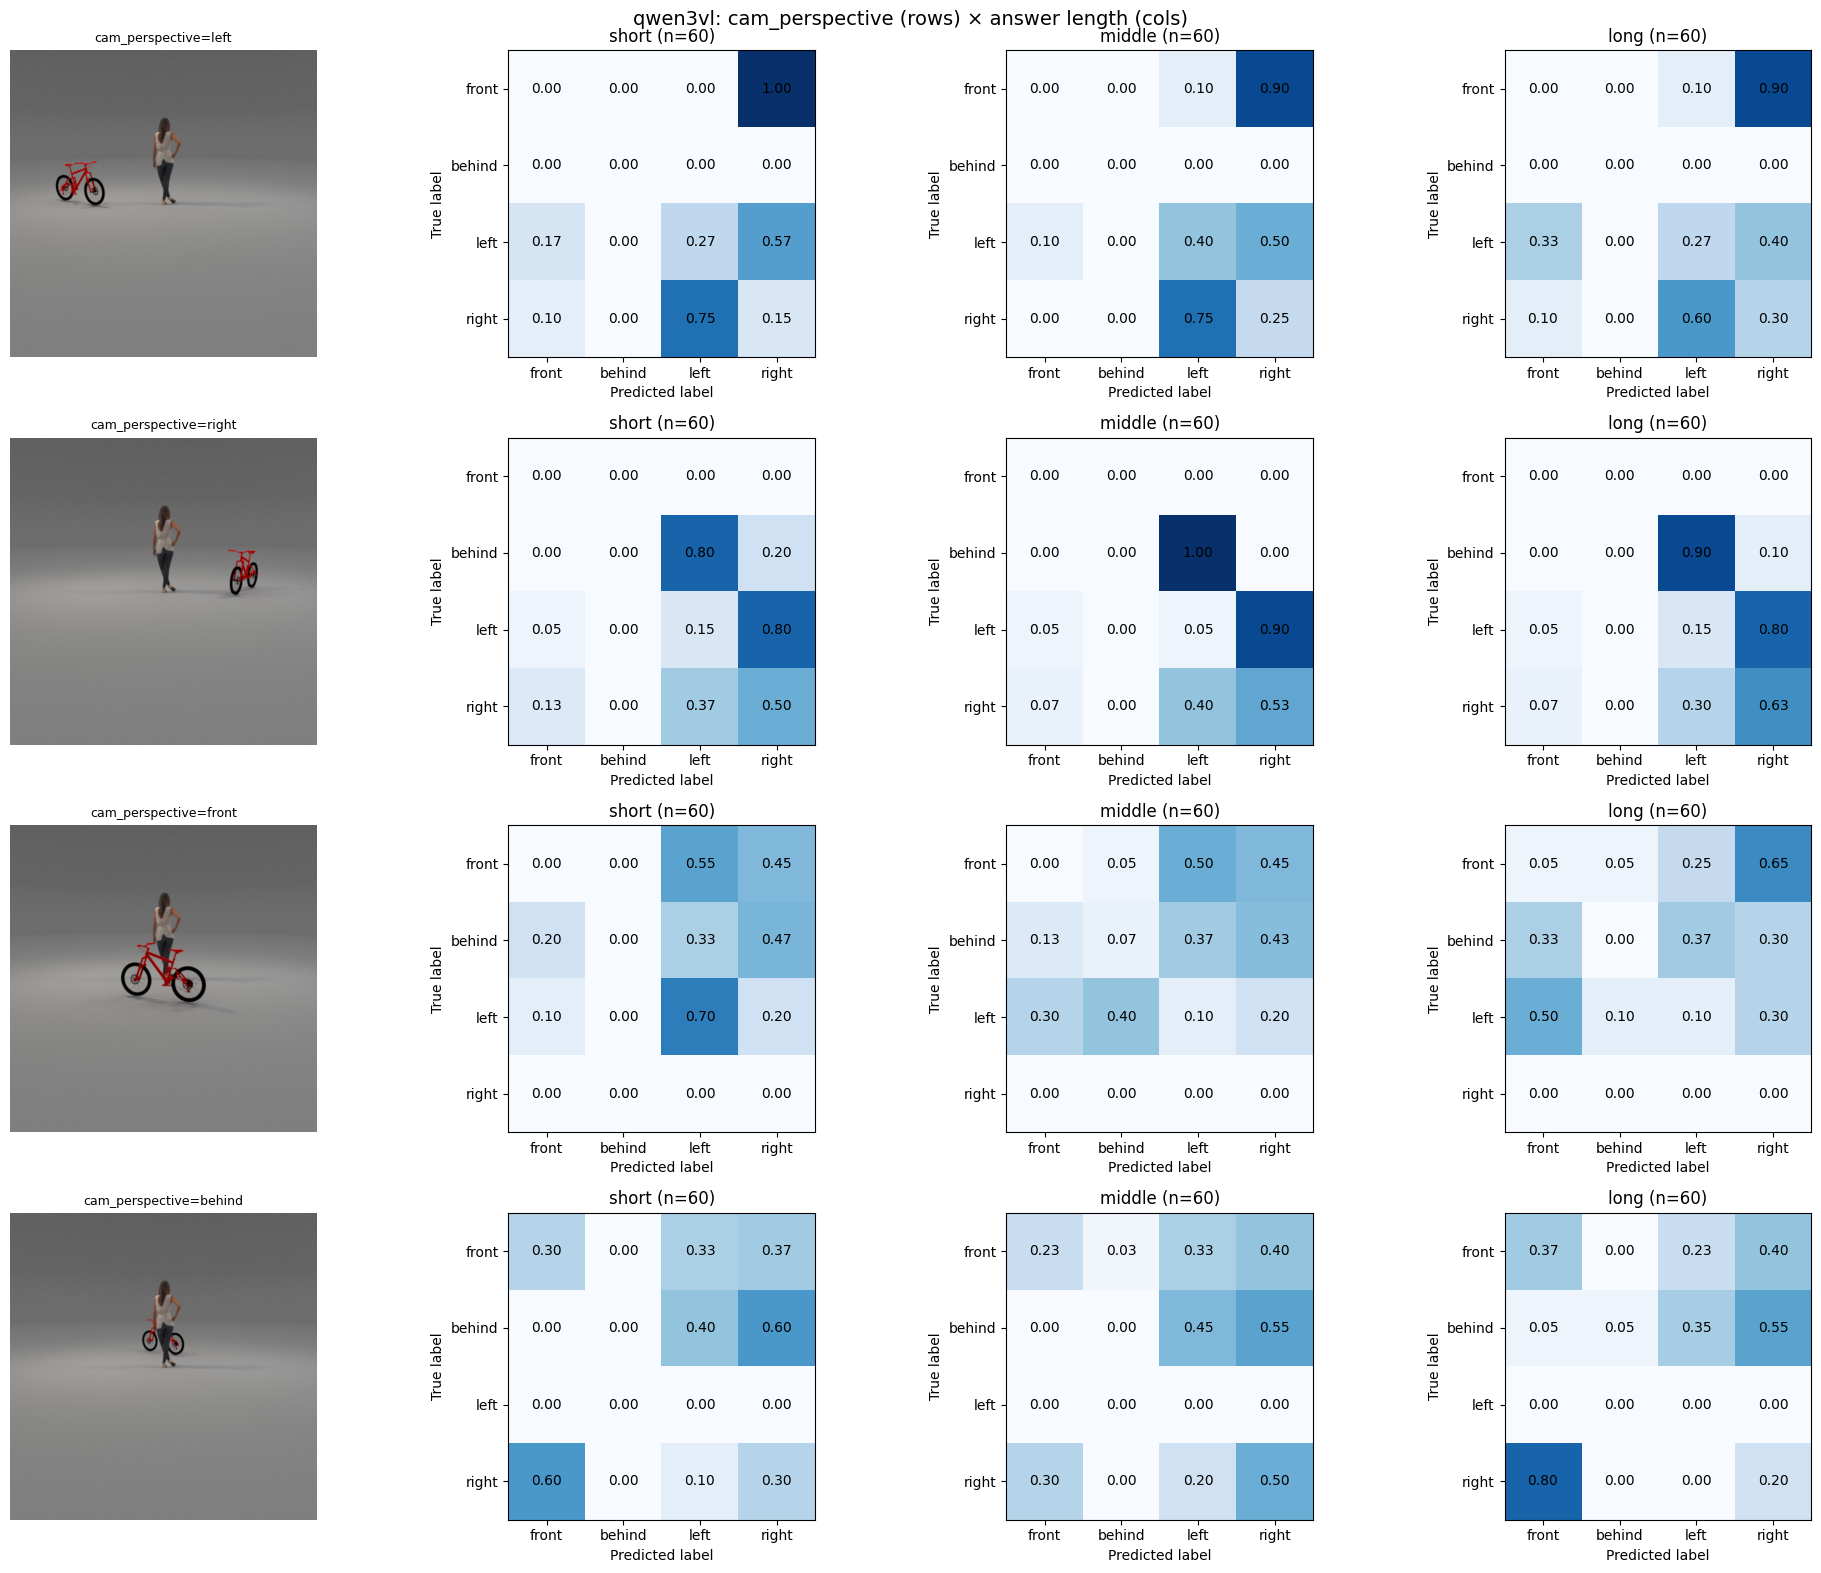

In [3]:
EXAMPLE_IMAGES = {
    "left":   "/home/zzou/COMFORT/data/comfort_human_car/totheleft/bicycle__totheleft__cam_back/0.png",
    "right":  "/home/zzou/COMFORT/data/comfort_human_car/totheright/bicycle__totheright__cam_back/0.png",
    "front":  "/home/zzou/COMFORT/data/comfort_human_car/behind/bicycle__behind__cam_back/0.png",
    "behind": "/home/zzou/COMFORT/data/comfort_human_car/infrontof/bicycle__infrontof__cam_back/0.png",
}

all_dfs = defaultdict(dict)

for model in models:
    print(f"\n===== MODEL: {model} =====")
    dfs = {}

    for length in lengths:
        csv_path = os.path.join(base_dir, f"pair_mcq_{length}_{model}.csv")
        if not os.path.exists(csv_path):
            print(f"  Missing: {csv_path}")
            continue
        df = load_and_prepare_pair(csv_path)
        dfs[length] = df
        all_dfs[model][length] = df
        print(f"  Loaded {length}: {len(df)} rows")

    if not dfs:
        continue

    for length in lengths:
        if length not in dfs:
            continue
        print(f"  [{length}]")
        display(analyze_percentages(dfs[length]))

    # 4 rows (object_position_under_cam_perspective) × (1 example img + 3 lengths)
    # Same layout as eval_analyse.ipynb
    OBJECT_POSITIONS = ["left", "right", "front", "behind"]
    fig, axes = plt.subplots(4, 4, figsize=(20, 16))

    for j, obj_pos in enumerate(OBJECT_POSITIONS):
        axes[j][0].imshow(plt.imread(EXAMPLE_IMAGES[obj_pos]))
        axes[j][0].axis("off")
        axes[j][0].set_title(f"cam_perspective={obj_pos}", fontsize=9)

        for i, length in enumerate(lengths):
            ax = axes[j][i + 1]
            if length not in dfs:
                ax.axis("off")
                continue
            # cam_perspective_1 = the perspective seen in image 1
            # use both perspectives: rows where either view shows obj_pos
            sub = dfs[length][
                (dfs[length]["cam_perspective_1"] == obj_pos) #|
                # (dfs[length]["cam_perspective_2"] == obj_pos)
            ]
            plot_confusion_on_ax(
                sub, ax,
                title=f"{length} (n={len(sub)})",
                true_labels=RELATIONS
            )

    fig.suptitle(f"{model}: cam_perspective (rows) × answer length (cols)", fontsize=14)
    plt.tight_layout()
    plt.show()

## 2 — View-pair accuracy heatmap (new analysis for paired images)

6 possible (cam_view_1, cam_view_2) combinations. Cell value = accuracy.

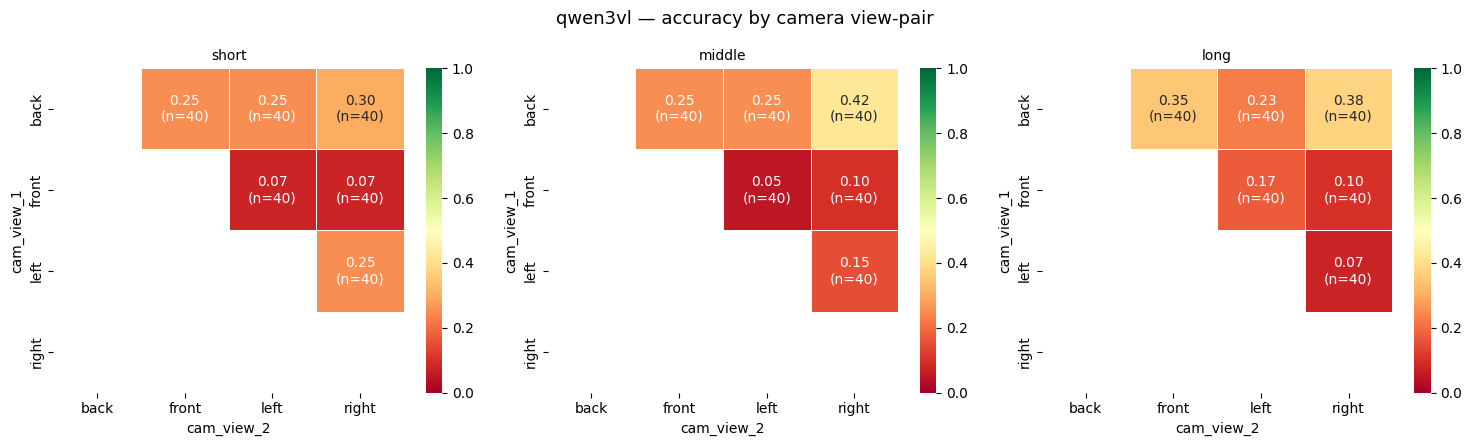

In [4]:
VIEW_SHORT = ["back", "front", "left", "right"]  # alphabetical = generation order

for model in models:
    available = [l for l in lengths if l in all_dfs.get(model, {})]
    if not available:
        continue

    fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 4.5))
    if len(available) == 1:
        axes = [axes]

    for ax, length in zip(axes, available):
        df = all_dfs[model][length]

        acc_matrix = np.full((4, 4), np.nan)
        n_matrix   = np.zeros((4, 4), dtype=int)
        for i, v1 in enumerate(VIEW_SHORT):
            for j, v2 in enumerate(VIEW_SHORT):
                if j <= i:
                    continue
                sub = df[(df["view1_short"] == v1) & (df["view2_short"] == v2)]
                if len(sub) == 0:
                    continue
                acc_matrix[i, j] = sub["is_correct"].mean()
                n_matrix[i, j]   = len(sub)

        annot = []
        for i in range(4):
            row = []
            for j in range(4):
                if np.isnan(acc_matrix[i, j]):
                    row.append("")
                else:
                    row.append(f"{acc_matrix[i, j]:.2f}\n(n={n_matrix[i, j]})")
            annot.append(row)

        mask_lower = np.tril(np.ones((4, 4), dtype=bool))

        sns.heatmap(
            acc_matrix,
            ax=ax,
            annot=annot,
            fmt="",
            mask=mask_lower,
            cmap="RdYlGn",
            vmin=0, vmax=1,
            linewidths=0.5,
            xticklabels=VIEW_SHORT,
            yticklabels=VIEW_SHORT,
            annot_kws={"size": 10},
            cbar=True,
        )
        ax.set_title(f"{length}", fontsize=10)
        ax.set_xlabel("cam_view_2")
        ax.set_ylabel("cam_view_1")

    fig.suptitle(f"{model} — accuracy by camera view-pair", fontsize=13)
    plt.tight_layout()
    plt.show()

## 3 — Confusion matrix per view-pair (6 combinations × 1 length)

Change `SELECTED_LENGTH` to inspect different answer lengths.

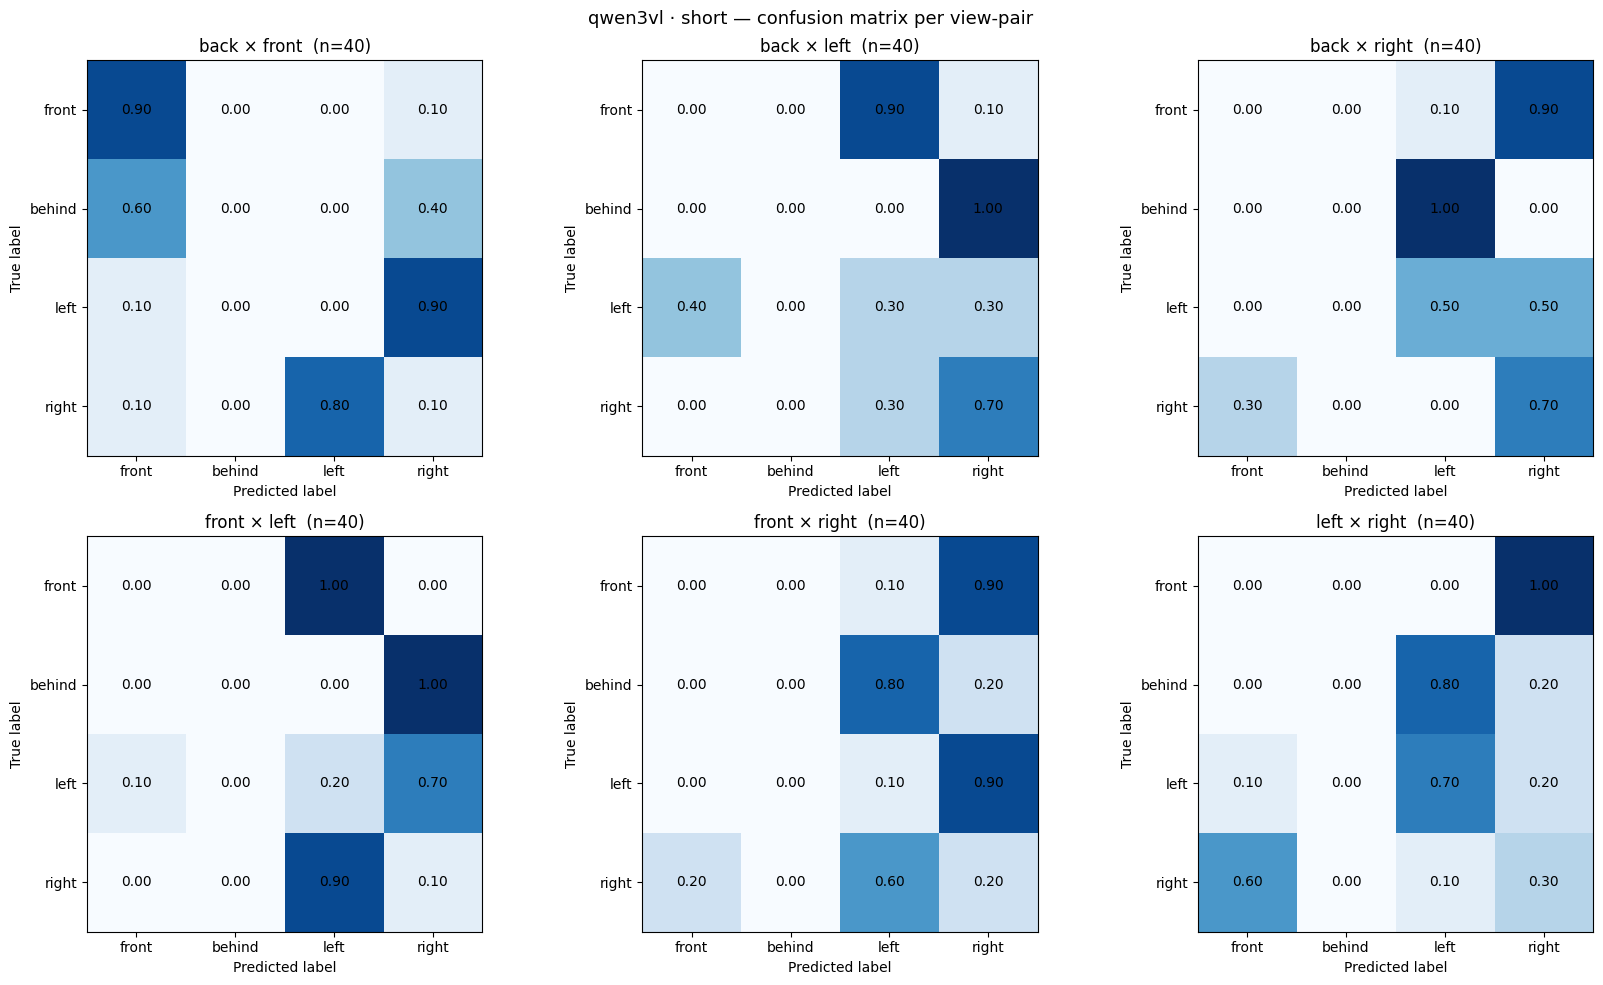

In [13]:
SELECTED_LENGTH = "short"  # ← change to "middle" or "long"

VIEW_PAIRS_ORDERED = [
    ("back",  "front"),
    ("back",  "left"),
    ("back",  "right"),
    ("front", "left"),
    ("front", "right"),
    ("left",  "right"),
]

for model in models:
    if SELECTED_LENGTH not in all_dfs.get(model, {}):
        print(f"{model}: no CSV for length={SELECTED_LENGTH}")
        continue

    df = all_dfs[model][SELECTED_LENGTH]
    fig, axes = plt.subplots(2, 3, figsize=(17, 10))

    for ax, (v1, v2) in zip(axes.flatten(), VIEW_PAIRS_ORDERED):
        sub = df[(df["view1_short"] == v1) & (df["view2_short"] == v2)]
        plot_confusion_on_ax(
            sub, ax,
            title=f"{v1} × {v2}  (n={len(sub)})",
            true_labels=RELATIONS
        )

    fig.suptitle(f"{model} · {SELECTED_LENGTH} — confusion matrix per view-pair", fontsize=13)
    plt.tight_layout()
    plt.show()


===== qwen3vl · short =====


,n,correct,cam_persp_1,cam_persp_2
view_pair,,,,
back × front,40,0.250,0.175,0.650
back × left,40,0.250,0.250,0.575
back × right,40,0.300,0.300,0.550
front × left,40,0.075,0.400,0.525
front × right,40,0.075,0.375,0.475
left × right,40,0.250,0.075,0.600


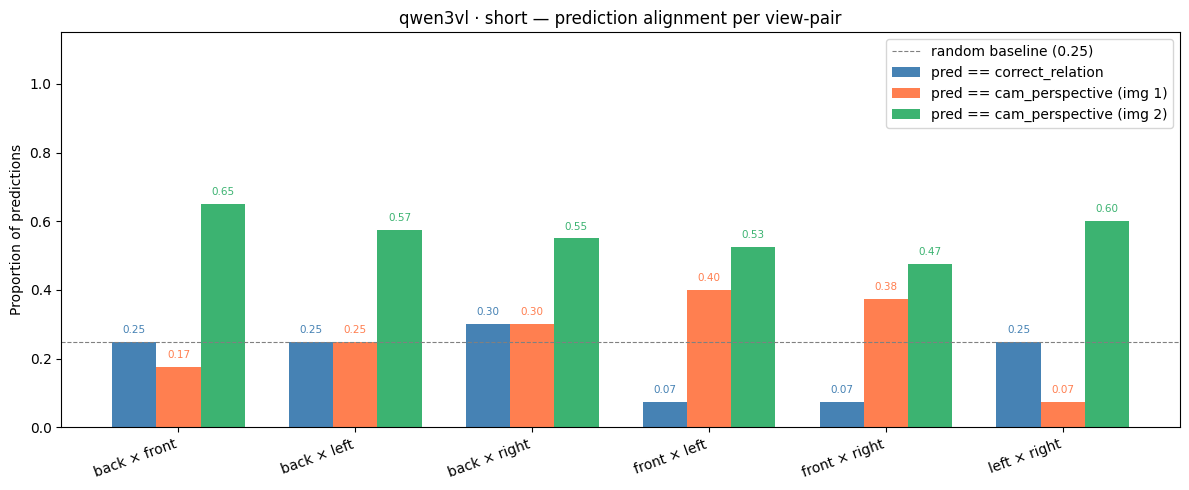

In [14]:
# ── 3b: Prediction alignment per view-pair ───────────────────────────────────
# For each (cam_view_1, cam_view_2) combination, compute how often the model's
# prediction matches:
#   (a) correct_relation  — the true spatial relation
#   (b) cam_perspective_1 — what the object looks like from camera 1's angle
#   (c) cam_perspective_2 — what the object looks like from camera 2's angle
#
# If cam_perspective rate >> correct rate → model is falling back to visual
# camera perspective rather than reasoning about the true relation.

for model in models:
    if SELECTED_LENGTH not in all_dfs.get(model, {}):
        print(f"{model}: no CSV for length={SELECTED_LENGTH}")
        continue

    df = all_dfs[model][SELECTED_LENGTH]

    rows = []
    for v1, v2 in VIEW_PAIRS_ORDERED:
        sub = df[(df["view1_short"] == v1) & (df["view2_short"] == v2)].copy()
        if len(sub) == 0:
            continue

        sub["match_correct"] = sub["pred_relation"] == sub["correct_relation"]
        sub["match_cam1"]    = sub["pred_relation"] == sub["cam_perspective_1"]
        sub["match_cam2"]    = sub["pred_relation"] == sub["cam_perspective_2"]

        rows.append({
            "view_pair":   f"{v1} × {v2}",
            "n":           len(sub),
            "correct":     sub["match_correct"].mean(),
            "cam_persp_1": sub["match_cam1"].mean(),
            "cam_persp_2": sub["match_cam2"].mean(),
        })

    result_df = pd.DataFrame(rows).set_index("view_pair")
    print(f"\n===== {model} · {SELECTED_LENGTH} =====")
    display(result_df.round(3))

    # grouped bar chart
    x = np.arange(len(rows))
    w = 0.25
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x - w, result_df["correct"],     w, label="pred == correct_relation",       color="steelblue")
    ax.bar(x,     result_df["cam_persp_1"], w, label="pred == cam_perspective (img 1)", color="coral")
    ax.bar(x + w, result_df["cam_persp_2"], w, label="pred == cam_perspective (img 2)", color="mediumseagreen")

    for i, row in enumerate(rows):
        for offset, key, color in [(-w, "correct", "steelblue"),
                                    (0,  "cam_persp_1", "coral"),
                                    (w,  "cam_persp_2", "mediumseagreen")]:
            val = row[key]
            ax.text(i + offset, val + 0.02, f"{val:.2f}",
                    ha="center", va="bottom", fontsize=7.5, color=color)

    ax.axhline(0.25, color="gray", linestyle="--", linewidth=0.8, label="random baseline (0.25)")
    ax.set_xticks(x)
    ax.set_xticklabels(result_df.index, rotation=20, ha="right")
    ax.set_ylim(0, 1.15)
    ax.set_ylabel("Proportion of predictions")
    ax.set_title(f"{model} · {SELECTED_LENGTH} — prediction alignment per view-pair")
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


## 4 — Δ accuracy: pair vs single-image

Loads the corresponding `mcq_{length}_{model}.csv` (single-image) and computes accuracy gain per relation.
**Positive Δ** = two images helped; **negative Δ** = single image was better.


===== qwen3vl =====
  [short]


,relation,single_acc,pair_acc,delta,n_single,n_pair
0,front,0.306,0.15,-0.156,36,60
1,behind,0.167,0.00,-0.167,36,60
2,left,0.333,0.30,-0.033,36,60
3,right,0.500,0.35,-0.150,36,60


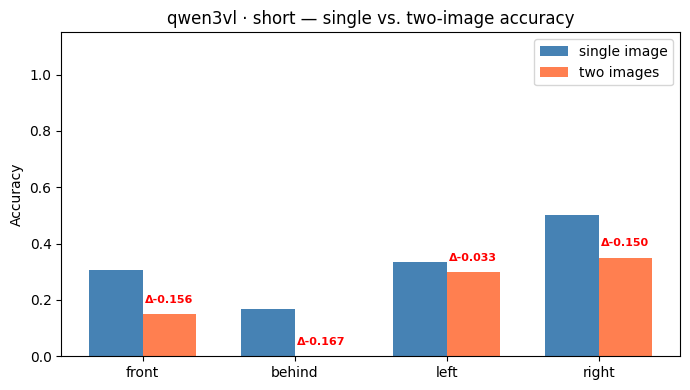

  [middle]


,relation,single_acc,pair_acc,delta,n_single,n_pair
0,front,0.222,0.117,-0.106,36,60
1,behind,0.194,0.033,-0.161,36,60
2,left,0.361,0.233,-0.128,36,60
3,right,0.361,0.433,0.072,36,60


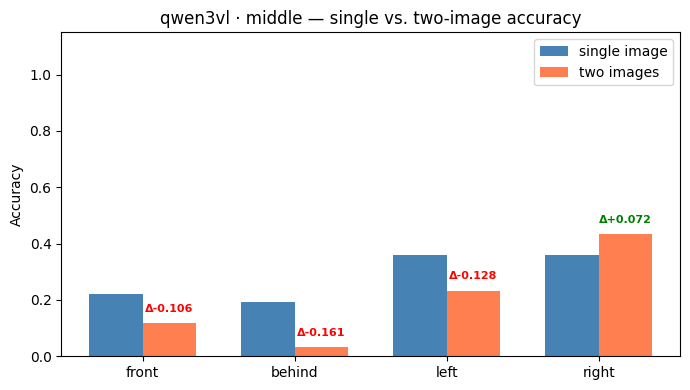

  [long]


,relation,single_acc,pair_acc,delta,n_single,n_pair
0,front,0.500,0.200,-0.300,36,60
1,behind,0.111,0.017,-0.094,36,60
2,left,0.417,0.200,-0.217,36,60
3,right,0.361,0.450,0.089,36,60


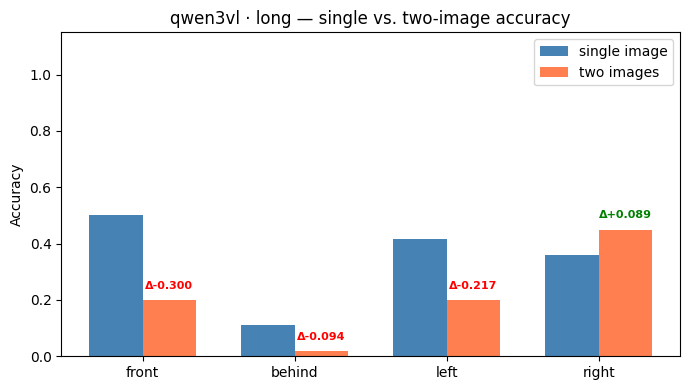

In [8]:
def load_single(csv_path):
    df = pd.read_csv(csv_path)
    def get_pred_relation(row):
        return extract_letter_to_relation(row["mcq_prompt"]).get(str(row["pred_letter"]).strip(), None)
    df["pred_relation"]   = df.apply(get_pred_relation, axis=1)
    df["correct_relation"] = df["correct_relation"].astype(str).str.strip().str.lower()
    df["is_correct"]  = df["pred_letter"].astype(str).str.strip() == df["correct_letter"].astype(str).str.strip()
    df["is_opposite"] = df["pred_letter"].astype(str).str.strip() == df["opposite_letter"].astype(str).str.strip()
    return df


for model in models:
    print(f"\n===== {model} =====")
    for length in lengths:
        pair_csv   = os.path.join(base_dir, f"pair_mcq_{length}_{model}.csv")
        single_csv = os.path.join(base_dir, f"mcq_{length}_{model}.csv")

        if not os.path.exists(pair_csv):
            print(f"  [{length}] no pair CSV, skip")
            continue
        if not os.path.exists(single_csv):
            print(f"  [{length}] no single CSV to compare, skip")
            continue

        df_pair = all_dfs[model].get(length)
        if df_pair is None:
            df_pair = load_and_prepare_pair(pair_csv)
        df_single = load_single(single_csv)

        rows = []
        for rel in RELATIONS:
            s_sub = df_single[df_single["correct_relation"] == rel]
            p_sub = df_pair[df_pair["correct_relation"] == rel]
            s_acc = s_sub["is_correct"].mean() if len(s_sub) > 0 else float("nan")
            p_acc = p_sub["is_correct"].mean() if len(p_sub) > 0 else float("nan")
            rows.append({
                "relation": rel,
                "single_acc": round(s_acc, 3),
                "pair_acc":   round(p_acc, 3),
                "delta":      round(p_acc - s_acc, 3),
                "n_single":   len(s_sub),
                "n_pair":     len(p_sub),
            })

        delta_df = pd.DataFrame(rows)
        print(f"  [{length}]")
        display(delta_df)

        x = np.arange(len(RELATIONS))
        w = 0.35
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(x - w/2, delta_df["single_acc"], w, label="single image", color="steelblue")
        ax.bar(x + w/2, delta_df["pair_acc"],   w, label="two images",   color="coral")
        ax.set_xticks(x)
        ax.set_xticklabels(RELATIONS)
        ax.set_ylim(0, 1.15)
        ax.set_ylabel("Accuracy")
        ax.set_title(f"{model} · {length} — single vs. two-image accuracy")
        ax.legend()
        for xi, row in zip(x, rows):
            delta = row["delta"]
            color = "green" if delta >= 0 else "red"
            ax.annotate(f"Δ{delta:+.3f}", (xi + w/2, row["pair_acc"] + 0.04),
                        ha="center", fontsize=8, color=color, fontweight="bold")
        plt.tight_layout()
        plt.show()